<a href="https://colab.research.google.com/github/daitianyuanya-code/brazilian-ecommerce-logistics-analysis/blob/main/olist_logistics_analysis_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delivery Delay Prediction and Seasonal Demand Analysis in Brazilian E-Commerce

**Research Question:** How can e-commerce platforms use order characteristics, holiday-period data, seller-side workload, and logistics risk profiles to identify delivery delay risks and improve logistics planning?

Most delivery delay prediction studies focus on static order-level characteristics such as product size, freight cost, and delivery distance. However, these features do not capture the operational context in which an order is fulfilled. Drawing on queuing theory's congestion logic — where service delays increase non-linearly as server utilisation approaches capacity — this project introduces a seller concurrent load variable. This variable measures the number of active unfulfilled orders a seller is handling when a new order is placed, capturing temporary supply-side capacity pressure that is not visible from order characteristics alone. The analysis tests whether this dynamic seller-level feature, combined with external calendar indicators and unsupervised cluster profiles, improves delay prediction beyond conventional order-level predictors.

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle) + Brazilian Public Holidays (external)

---

**Notebook structure:**
1. Setup & Data Loading
2. Data Preprocessing (concise — merge, clean, feature engineering)
3. External Data — Brazilian Public Holidays
4. Exploratory Data Analysis
5. Unsupervised Learning — K-Means Clustering
6. Supervised Learning — Delay Classification (Logistic Regression + Random Forest + XGBoost)
7. Results & Business Recommendations

## 1. Setup & Data Loading

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset (1).csv


In [ ]:
# Load the six uploaded Olist CSV files

DATA_DIR = ""

orders = pd.read_csv(DATA_DIR + "olist_orders_dataset.csv")
items = pd.read_csv(DATA_DIR + "olist_order_items_dataset.csv")
reviews = pd.read_csv(DATA_DIR + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(DATA_DIR + "olist_customers_dataset.csv")
sellers = pd.read_csv(DATA_DIR + "olist_sellers_dataset (1).csv")
products = pd.read_csv(DATA_DIR + "olist_products_dataset.csv")

print(f"Orders:    {orders.shape}")
print(f"Items:     {items.shape}")
print(f"Reviews:   {reviews.shape}")
print(f"Customers: {customers.shape}")
print(f"Sellers:   {sellers.shape}")
print(f"Products:  {products.shape}")

Orders:    (99441, 8)
Items:     (112650, 7)
Reviews:   (99224, 7)
Customers: (99441, 5)
Sellers:   (3095, 4)
Products:  (32951, 9)


## 2. Data Preprocessing

### 2.1 Merge tables into one analytical DataFrame

Before merging the datasets, I define the unit of analysis as the order level. This means that each row in the final analytical DataFrame should represent one order. Since the Olist data is stored across multiple relational tables, I merge customer, seller, product, item, and review information into the orders table.

Some tables contain multiple rows per order. For example, the order items table may include several products within the same order. Therefore, these tables need to be aggregated to order level before merging. This avoids creating duplicated order rows in the final dataset.

In [ ]:
# ============================================================
# 2.1 Merge tables into one order-level analytical DataFrame
# ============================================================

# ------------------------------------------------------------
# Step 1: Start from the orders table and add customer location
# ------------------------------------------------------------
# The orders table is used as the base table because the final unit
# of analysis is one row per order.
# Customer city and state are added to capture demand-side location information.

df = orders.merge(
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

print("After merging customer information:", df.shape)

After merging customer information: (99441, 10)


In [ ]:
# ------------------------------------------------------------
# Step 2: Aggregate order item information to order level
# ------------------------------------------------------------
# The order_items table can contain multiple rows for the same order,
# because one order may include more than one product and may involve
# more than one seller.
#
# Since the final analytical dataset is defined at order level, item-level
# variables need to be aggregated before merging with the orders table.
# Price and freight are summed, item_count captures the number of items,
# seller_id keeps the first seller for merging seller location, and
# seller_count records how many unique sellers are involved in each order.

items_agg = items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'max'),
    seller_id=('seller_id', 'first'),
    seller_count=('seller_id', 'nunique')
).reset_index()

df = df.merge(items_agg, on='order_id', how='left')

print("After merging aggregated order item information:", df.shape)

After merging aggregated order item information: (99441, 15)


In [ ]:
# ------------------------------------------------------------
# Step 3: Add product characteristics at order level
# ------------------------------------------------------------
# Product information is first merged into the item-level table.
# Then product weight and product volume are aggregated to order level.
# This is necessary because one order may contain multiple products.

items_products = items[['order_id', 'product_id']].merge(
    products[
        [
            'product_id',
            'product_category_name',
            'product_weight_g',
            'product_length_cm',
            'product_height_cm',
            'product_width_cm'
        ]
    ],
    on='product_id',
    how='left'
)

# Calculate product volume using length × height × width.
items_products['product_volume_cm3'] = (
    items_products['product_length_cm'] *
    items_products['product_height_cm'] *
    items_products['product_width_cm']
)

product_agg = items_products.groupby('order_id').agg(
    product_weight_g=('product_weight_g', 'sum'),
    product_volume_cm3=('product_volume_cm3', 'sum'),
    product_category_name=('product_category_name', 'first')
).reset_index()

df = df.merge(product_agg, on='order_id', how='left')

print("After merging aggregated product information:", df.shape)

After merging aggregated product information: (99441, 18)


In [ ]:
# ------------------------------------------------------------
# Step 4: Add seller location
# ------------------------------------------------------------
# Seller state is added to capture supply-side location information.
# This can later be used to compare customer and seller regions.

df = df.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)

print("After merging seller information:", df.shape)

After merging seller information: (99441, 19)


In [ ]:
# ------------------------------------------------------------
# Step 5: Add review score
# ------------------------------------------------------------
# Review scores are aggregated to order level.
# The mean is used in case there is more than one review for an order.

review_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()

df = df.merge(review_agg, on='order_id', how='left')

print("After merging review information:", df.shape)


After merging review information: (99441, 20)


In [ ]:
# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------
print("Final analytical DataFrame shape:", df.shape)
df.head()

Final analytical DataFrame shape: (99441, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,total_price,total_freight,item_count,seller_id,seller_count,product_weight_g,product_volume_cm3,product_category_name,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,29.99,8.72,1.0,3504c0cb71d7fa48d967e0e4c94d59d9,1.0,500.0,1976.0,utilidades_domesticas,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,118.70,22.76,1.0,289cdb325fb7e7f891c38608bf9e0962,1.0,400.0,4693.0,perfumaria,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,159.90,19.22,1.0,4869f7a5dfa277a7dca6462dcf3b52b2,1.0,420.0,9576.0,automotivo,SP,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,45.00,27.20,1.0,66922902710d126a0e7d26b0e3805106,1.0,450.0,6000.0,pet_shop,MG,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,19.90,8.72,1.0,2c9e548be18521d1c43cde1c582c6de8,1.0,250.0,11475.0,papelaria,SP,5.0


In [ ]:
df.head()

### 2.2 Parse date columns

The order date variables are originally stored as text. Before calculating delivery-related metrics, these columns need to be converted into datetime format using `pd.to_datetime()`. This allows Python to correctly calculate time differences between order purchase, actual delivery, and estimated delivery dates.

In [ ]:
# ============================================================
# 2.2 Parse date columns
# ============================================================

# Convert date columns from text to datetime format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print("Date columns converted successfully.")
df[date_cols].dtypes

Date columns converted successfully.


,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


### 2.3 Filter & clean Keep delivered orders only

This analysis focuses on delivery performance. Therefore, I keep only orders with the status `delivered`, because cancelled, unavailable, or undelivered orders do not have valid actual customer delivery dates. This filtering step is performed before creating delay-related variables to avoid incorrectly treating undelivered orders as non-delayed orders.

In [ ]:
# ============================================================
# 2.3 Keep delivered orders only
# ============================================================
# This analysis focuses on delivery performance.
# Therefore, only delivered orders are retained because cancelled,
# unavailable, or undelivered orders do not have valid actual
# customer delivery dates.

print(f"Before filtering: {len(df)} orders")

df = df[df['order_status'] == 'delivered'].copy()

print(f"After keeping delivered orders: {len(df)} orders")

Before filtering: 99441 orders
After keeping delivered orders: 96478 orders


### 2.4 Create delivery performance metrics

After keeping only delivered orders, I create delivery-related variables for analysis and modelling. `delivery_days` measures the actual number of days between purchase and customer delivery. `delay_days` compares the actual delivery date with the estimated delivery date, where a positive value means the order was delivered later than expected. Based on this, I create the binary target variable `is_delayed`, where 1 indicates delayed delivery and 0 indicates on-time or early delivery. I also create `estimated_window`, which represents the promised delivery window known at the time of purchase.

In [ ]:
# ============================================================
# 2.4 Create delivery performance metrics
# ============================================================

# Actual delivery duration: purchase date to customer delivery date
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

# Delivery delay: actual delivery date minus estimated delivery date
# Positive values indicate late delivery
df['delay_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

# Binary target variable for supervised learning
# 1 = delayed delivery, 0 = on-time or early delivery
df['is_delayed'] = (df['delay_days'] > 0).astype(int)

# Estimated delivery window known at the time of purchase
df['estimated_window'] = (
    df['order_estimated_delivery_date'] -
    df['order_purchase_timestamp']
).dt.days

# Check summary statistics for the new variables
df[['delivery_days', 'delay_days', 'is_delayed', 'estimated_window']].describe()

,delivery_days,delay_days,is_delayed,estimated_window
count,96470.000000,96470.000000,96478.000000,96478.000000
mean,12.093604,-11.875889,0.067725,23.372759
std,9.551380,10.182105,0.251275,8.758137
min,0.000000,-147.000000,0.000000,2.000000
25%,6.000000,-17.000000,0.000000,18.000000
50%,10.000000,-12.000000,0.000000,23.000000
75%,15.000000,-7.000000,0.000000,28.000000
max,209.000000,188.000000,1.000000,155.000000


### 2.5 Check and handle missing values

After creating the delivery performance variables, I check missing values in the key analytical columns. This step is necessary because missing values can affect exploratory analysis and machine learning models. I focus on variables that will be used later for modelling, including delivery metrics, price and freight information, product characteristics, review score, and location variables.

For essential variables such as delivery metrics, price, freight, and location information, rows with missing values are removed. For product weight, product volume, and review score, missing values are filled with the median because these variables may be right-skewed and the median is less sensitive to extreme values than the mean.

In [ ]:
# ============================================================
# 2.5 Check and handle missing values
# ============================================================

# Select key variables for analysis and modelling
key_cols = [
    'delivery_days',
    'delay_days',
    'is_delayed',
    'estimated_window',
    'total_price',
    'total_freight',
    'item_count',
    'seller_count',
    'product_weight_g',
    'product_volume_cm3',
    'review_score',
    'customer_state',
    'seller_state'
]

# Check missing values before cleaning
missing_before = df[key_cols].isna().sum().sort_values(ascending=False)

print("Missing values before cleaning:")
display(missing_before[missing_before > 0])

print(f"Rows before missing value cleaning: {len(df)}")

# Drop rows where essential variables are missing
essential_cols = [
    'delivery_days',
    'delay_days',
    'is_delayed',
    'estimated_window',
    'total_price',
    'total_freight',
    'item_count',
    'seller_count',
    'customer_state',
    'seller_state'
]

df = df.dropna(subset=essential_cols).copy()

# Fill missing product characteristics and review score with median values
df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())
df['product_volume_cm3'] = df['product_volume_cm3'].fillna(df['product_volume_cm3'].median())
df['review_score'] = df['review_score'].fillna(df['review_score'].median())

print(f"Rows after missing value cleaning: {len(df)}")

# Check missing values after cleaning
missing_after = df[key_cols].isna().sum().sort_values(ascending=False)

print("Missing values after cleaning:")
display(missing_after[missing_after > 0])

Missing values before cleaning:


,0
review_score,646
delay_days,8
delivery_days,8


Rows before missing value cleaning: 96478
Rows after missing value cleaning: 96470
Missing values after cleaning:


,0


### 2.6 Create additional explanatory features

I create two additional variables that may help explain delivery performance. `is_cross_state` indicates whether the customer and seller are located in different states. This can reflect more complex logistics routes and may be associated with longer delivery times or higher delay risk. `purchase_month` captures the month of purchase, which may represent seasonal patterns in logistics demand, such as sales periods or holiday-related delivery pressure.

I also remove duplicate order IDs as a final consistency check to ensure that the dataset remains at order level.

In [ ]:
# ============================================================
# 2.6 Create additional explanatory features
# ============================================================

# Whether the customer and seller are located in different states
df['is_cross_state'] = (df['customer_state'] != df['seller_state']).astype(int)

# Month of purchase, used to capture possible seasonal effects
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

# Remove duplicate order IDs if any exist
n_before = len(df)
df = df.drop_duplicates(subset=['order_id'], keep='first').copy()

print(f"Removed {n_before - len(df)} duplicate order_id rows")
print(f"Final dataset shape: {df.shape}")

# Preview the final cleaned dataset
df.head()

Removed 0 duplicate order_id rows
Final dataset shape: (96470, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,product_volume_cm3,product_category_name,seller_state,review_score,delivery_days,delay_days,is_delayed,estimated_window,is_cross_state,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,1976.0,utilidades_domesticas,SP,4.0,8.0,-8.0,0,15,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,...,4693.0,perfumaria,SP,4.0,13.0,-6.0,0,19,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,...,9576.0,automotivo,SP,5.0,9.0,-18.0,0,26,1,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,...,6000.0,pet_shop,MG,5.0,13.0,-13.0,0,26,1,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,...,11475.0,papelaria,SP,5.0,2.0,-10.0,0,12,0,2


### 2.6a Create seller concurrent order load

To capture seller-side capacity pressure, I construct a variable that counts how many orders from the same seller were already in progress (purchased but not yet delivered) when each focal order was placed. This variable is motivated by queuing theory: when a seller's active workload is high, processing delays are more likely. The variable is constructed from the raw `orders` and `items` tables and then aggregated to order level.

In [ ]:
# ============================================================
# 2.6a Create seller concurrent order load
# ============================================================
# This step measures seller-side capacity pressure using the number of active seller orders at purchase time, rather than relying only on static order features.
# For each order-seller pair, count how many of that seller's
# previous orders were active (purchased but not yet delivered)
# at the time the focal order was placed.

# Merge seller IDs with order timestamps so concurrent load can be calculated at the seller-order level.
seller_orders = items[['order_id', 'seller_id']].drop_duplicates().merge(
    orders[['order_id', 'order_purchase_timestamp',
            'order_delivered_customer_date', 'order_status']],
    on='order_id', how='left'
)

# Keep delivered orders only and convert timestamps so the active-order definition is consistent.
seller_orders = seller_orders[seller_orders['order_status'] == 'delivered'].copy()
seller_orders['order_purchase_timestamp'] = pd.to_datetime(seller_orders['order_purchase_timestamp'])
seller_orders['order_delivered_customer_date'] = pd.to_datetime(seller_orders['order_delivered_customer_date'])
seller_orders = seller_orders.sort_values(['seller_id', 'order_purchase_timestamp']).reset_index(drop=True)


def calculate_seller_load(group):
    """
    For each order within a seller group, count how many previous orders
    were still active (purchased before current time AND not yet delivered).
    """
    # Look back within each seller's chronological order history to approximate the actual queue pressure at purchase time.
    purchase = group['order_purchase_timestamp'].values
    delivered = group['order_delivered_customer_date'].values
    loads = []
    for i, current_time in enumerate(purchase):
        active = ((purchase[:i] < current_time) & (delivered[:i] > current_time)).sum()
        loads.append(active)
    group['seller_concurrent_load'] = loads
    return group


# Calculate load within each seller group so orders from different sellers do not affect one another.
seller_orders = seller_orders.groupby('seller_id', group_keys=False).apply(calculate_seller_load)

# Aggregate to order level because one order can involve multiple sellers, matching the granularity of the main dataframe.
seller_load_order = seller_orders.groupby('order_id').agg(
    seller_concurrent_load_mean=('seller_concurrent_load', 'mean'),
    seller_concurrent_load_max=('seller_concurrent_load', 'max')
).reset_index()

# Merge seller load back into the main dataframe and fill missing values with 0 when no observable concurrent load exists.
df = df.merge(seller_load_order, on='order_id', how='left')
df['seller_concurrent_load_mean'] = df['seller_concurrent_load_mean'].fillna(0)
df['seller_concurrent_load_max'] = df['seller_concurrent_load_max'].fillna(0)

# Use the 75th percentile to define high-load orders for later EDA and diagnostic comparisons.
load_threshold = df['seller_concurrent_load_max'].quantile(0.75)
df['is_high_seller_load'] = (df['seller_concurrent_load_max'] >= load_threshold).astype(int)

print("Seller concurrent load variables created.")
print(f"75th percentile load threshold: {load_threshold}")
display(df[['seller_concurrent_load_mean', 'seller_concurrent_load_max', 'is_high_seller_load']].describe())

### 2.7 Quick summary of the cleaned Olist dataset

As a final preprocessing check, I summarise the main delivery outcome variables after cleaning the internal Olist dataset. This provides an overview of the delayed delivery rate, average delivery duration, and average delay days before adding external holiday information. This step also helps confirm that the target variable and delivery metrics have been created correctly.

In [ ]:
# ============================================================
# 2.7 Quick summary of the cleaned Olist dataset
# ============================================================

print(f"Cleaned Olist dataset shape: {df.shape}")
print(f"Delay rate: {df['is_delayed'].mean():.2%}")
print(f"Average delivery days: {df['delivery_days'].mean():.1f}")
print(f"Average delay days: {df['delay_days'].mean():.1f}")
print(f"Average estimated delivery window: {df['estimated_window'].mean():.1f}")

# Check the distribution of the binary target variable
print("\nTarget variable distribution:")
display(df['is_delayed'].value_counts())
display(df['is_delayed'].value_counts(normalize=True))

# Summary statistics for main numerical variables
summary_cols = [
    'delivery_days',
    'delay_days',
    'estimated_window',
    'total_price',
    'total_freight',
    'item_count',
    'seller_count',
    'product_weight_g',
    'product_volume_cm3',
    'review_score'
]

df[summary_cols].describe()

Cleaned Olist dataset shape: (96470, 26)
Delay rate: 6.77%
Average delivery days: 12.1
Average delay days: -11.9
Average estimated delivery window: 23.4

Target variable distribution:


,count
is_delayed,
0,89936
1,6534


,proportion
is_delayed,
0,0.932269
1,0.067731


,delivery_days,delay_days,estimated_window,total_price,total_freight,item_count,seller_count,product_weight_g,product_volume_cm3,review_score
count,96470.000000,96470.000000,96470.000000,96470.000000,96470.000000,96470.000000,96470.000000,96470.000000,9.647000e+04,96470.000000
mean,12.093604,-11.875889,23.372748,137.040001,22.785798,1.142210,1.013901,2386.472437,1.732906e+04,4.161809
std,9.551380,10.182105,8.758421,209.052608,21.559959,0.538824,0.123542,4769.813318,3.014220e+04,1.281159
min,0.000000,-147.000000,2.000000,0.850000,0.000000,1.000000,1.000000,0.000000,0.000000e+00,1.000000
25%,6.000000,-17.000000,18.000000,45.900000,13.850000,1.000000,1.000000,300.000000,2.964000e+03,4.000000
50%,10.000000,-12.000000,23.000000,86.500000,17.170000,1.000000,1.000000,750.000000,7.250000e+03,5.000000
75%,15.000000,-7.000000,28.000000,149.900000,24.020000,1.000000,1.000000,2050.000000,1.986600e+04,5.000000
max,209.000000,188.000000,155.000000,13440.000000,1794.960000,21.000000,5.000000,184400.000000,1.476000e+06,5.000000


The cleaned Olist dataset contains 96,470 orders and 26 variables. The target variable shows that 6.77% of delivered orders were delayed, while 93.23% were delivered on time or earlier than the estimated delivery date. This indicates that the classification task is imbalanced, because delayed orders represent a relatively small proportion of the dataset.

On average, orders were delivered in 12.1 days. The average delay days is -11.9, which means that most orders were delivered earlier than the estimated delivery date. The average estimated delivery window is 23.4 days, suggesting that Olist's estimated delivery dates were generally conservative.

These summary statistics confirm that the cleaned dataset is suitable for further exploratory analysis and modelling. However, the imbalance in the target variable should be considered when interpreting supervised learning results.

## 3. External Data — Brazilian Public Holidays

The Olist dataset captures order-level logistics information, but it does not directly include external calendar effects. Public holidays may affect logistics performance by increasing order demand, reducing working days, or creating temporary delivery bottlenecks. Therefore, I add Brazilian public holiday information as an external contextual variable before conducting exploratory analysis and modelling.

The holiday dates are generated using the Python `holidays` library for the Olist data period from 2016 to 2018. I then use date-based matching to identify whether each order was purchased within a 7-day window before or after a Brazilian public holiday. This creates a holiday-period indicator that can be used to examine whether holiday-adjacent orders are associated with higher delivery delay risk.

The 7-day window is an analytical assumption used to capture possible pre-holiday and post-holiday logistics effects, rather than an official holiday definition.

In [ ]:
# ============================================================
# 3.1 Generate Brazilian public holiday dates
# ============================================================

import holidays

# Generate Brazilian public holidays for the Olist data period
br_holidays = holidays.Brazil(years=[2016, 2017, 2018])
holiday_dates = sorted(br_holidays.keys())

print(f"Total Brazilian public holidays from 2016 to 2018: {len(holiday_dates)}")

# Display the first few holiday dates as a check
for d in holiday_dates[:8]:
    print(f"{d}: {br_holidays[d]}")

Total Brazilian public holidays from 2016 to 2018: 27
2016-01-01: Universal Fraternization Day
2016-03-25: Good Friday
2016-04-21: Tiradentes' Day
2016-05-01: Worker's Day
2016-09-07: Independence Day
2016-10-12: Our Lady of Aparecida
2016-11-02: All Souls' Day
2016-11-15: Republic Proclamation Day


In [ ]:
# ============================================================
# 3.2 Create holiday-period indicator
# ============================================================

# Build a set of dates within 7 days before or after each public holiday
holiday_window_set = set()

for d in holiday_dates:
    for offset in range(-7, 8):
        holiday_window_set.add(pd.Timestamp(d) + pd.Timedelta(days=offset))

# Convert order purchase timestamp to date level for matching
df['purchase_date'] = df['order_purchase_timestamp'].dt.normalize()

# Flag whether the purchase date is within the holiday window
df['is_holiday_period'] = df['purchase_date'].isin(holiday_window_set).astype(int)

print("Holiday-period variable created.")
print(df['is_holiday_period'].value_counts())
print(df['is_holiday_period'].value_counts(normalize=True))

Holiday-period variable created.
is_holiday_period
0    71988
1    24482
Name: count, dtype: int64
is_holiday_period
0    0.746222
1    0.253778
Name: proportion, dtype: float64


The holiday-period indicator shows that 25.38% of orders were placed within seven days before or after a Brazilian public holiday. This proportion is relatively large because the holiday window includes both pre-holiday and post-holiday periods rather than only the holiday date itself.

### 3.3 Create peak-season indicators

In addition to official public holidays, I create simple indicators for major shopping or seasonal periods. Black Friday is included because it may generate high order volumes and logistics pressure, while the Christmas period may affect delivery capacity and customer expectations. These variables are treated as contextual peak-season indicators rather than official public holiday variables.

In [ ]:
# ============================================================
# 3.3 Create peak-season indicators
# ============================================================

# Black Friday period: late November
df['is_black_friday_period'] = (
    (df['purchase_date'].dt.month == 11) &
    (df['purchase_date'].dt.day >= 20) &
    (df['purchase_date'].dt.day <= 30)
).astype(int)

# Christmas period: mid to late December
df['is_christmas_period'] = (
    (df['purchase_date'].dt.month == 12) &
    (df['purchase_date'].dt.day >= 15) &
    (df['purchase_date'].dt.day <= 31)
).astype(int)

print("Peak-season variables created.")

display(df[
    ['is_holiday_period', 'is_black_friday_period', 'is_christmas_period']
].mean().sort_values(ascending=False))

Peak-season variables created.


,0
is_holiday_period,0.253778
is_black_friday_period,0.044107
is_christmas_period,0.023365


The peak-season indicators show that 4.41% of orders fall within the Black Friday period and 2.34% fall within the Christmas period. These variables are not official public-holiday measures, but contextual indicators designed to capture potential demand surges and seasonal logistics pressure.

### 3.4 Check delay patterns during holiday periods

After creating the holiday-period indicator, I compare delivery outcomes between normal periods and holiday-adjacent periods. This provides an initial check of whether holiday periods are associated with different logistics performance. The comparison includes delay rate, average delay days, average delivery duration, and review score.

In [ ]:
# ============================================================
# 3.4 Compare delivery performance: holiday vs normal periods
# ============================================================

comparison = df.groupby('is_holiday_period').agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_review_score=('review_score', 'mean')
).round(3)

# Rename index for readability
comparison.index = comparison.index.map({
    0: 'Normal Period',
    1: 'Holiday Period'
})

display(comparison)

,order_count,delay_rate,avg_delay_days,avg_delivery_days,avg_review_score
is_holiday_period,,,,,
Normal Period,71988,0.072,-11.820,12.038,4.153
Holiday Period,24482,0.056,-12.041,12.256,4.187


The comparison shows an interesting pattern. **Holiday-period orders have a lower delay rate than normal-period orders**, but their **average delivery duration is slightly longer**. This means that public holidays may slow down actual delivery time, but they do not necessarily increase the probability of being classified as delayed. A possible explanation is that **estimated delivery windows may already be more conservative around holiday periods**, which reduces the chance that an order is labelled as late. Therefore, the holiday effect should be **interpreted cautiously** and further examined in the EDA and modelling sections.



## 4. Exploratory Data Analysis

This section explores the cleaned and enriched order-level dataset before applying machine learning models. The purpose of EDA is to understand the distribution of the target variable, identify important delivery patterns, and examine whether logistics-related features such as delivery distance proxy, holiday periods, seasonality, freight cost, and review score are associated with delivery delays.

The analysis focuses on both descriptive patterns and potential modelling implications.

### 4.1 Target variable distribution

The target variable for supervised learning is `is_delayed`, where 1 indicates that an order was delivered after the estimated delivery date, and 0 indicates that it was delivered on time or earlier. I first examine the distribution of this variable to understand whether the classification problem is balanced or imbalanced.

Target counts:


,count
is_delayed,
0,89936
1,6534


Target proportions:


,proportion
is_delayed,
0,0.932269
1,0.067731


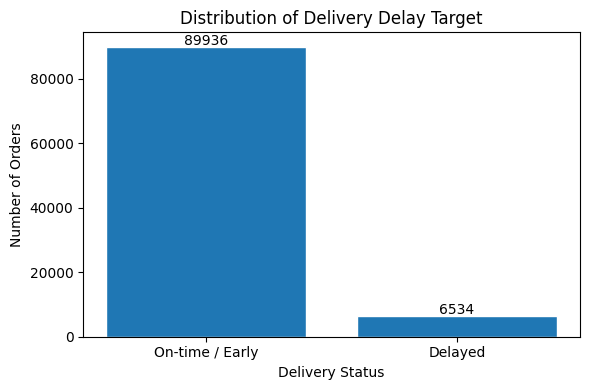

In [ ]:
# ============================================================
# 4.1 Target variable distribution
# ============================================================

target_counts = df['is_delayed'].value_counts().sort_index()
target_rates = df['is_delayed'].value_counts(normalize=True).sort_index()

print("Target counts:")
display(target_counts)

print("Target proportions:")
display(target_rates)

plt.figure(figsize=(6, 4))
plt.bar(['On-time / Early', 'Delayed'], target_counts.values, edgecolor='white')
plt.title('Distribution of Delivery Delay Target')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 500, str(v), ha='center')

plt.tight_layout()
plt.show()

The target variable is highly imbalanced. Only 6.77% of delivered orders are classified as delayed, while 93.23% are delivered on time or earlier than the estimated delivery date. This does not indicate a data error. Instead, it reflects the current delay definition, where an order is delayed only if the actual delivery date is later than the estimated delivery date.

This imbalance has important implications for supervised learning. Accuracy alone may be misleading, because a model could achieve high accuracy simply by predicting most orders as non-delayed. Therefore, model evaluation should also consider precision, recall, F1-score, confusion matrix, and ROC-AUC.

### 4.2 Delivery time and delay distribution

I then examine the distributions of actual delivery duration and delay days. `delivery_days` measures how long delivery took, while `delay_days` compares actual delivery with the estimated delivery date. Negative delay values indicate early delivery, while positive values indicate late delivery.

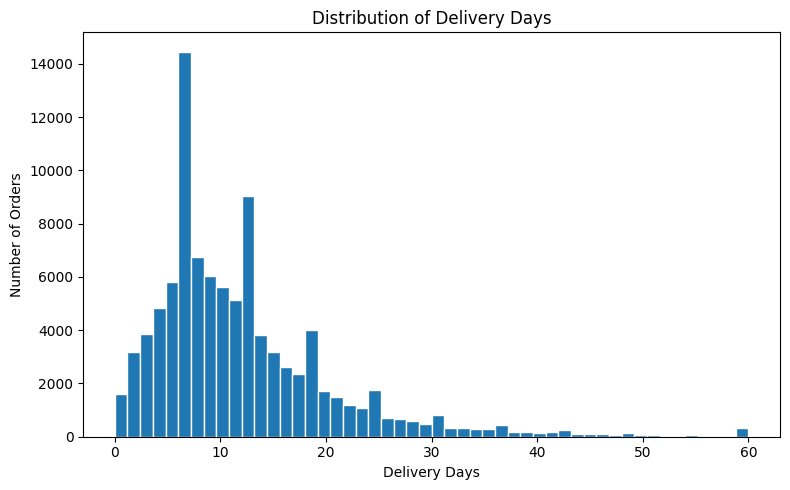

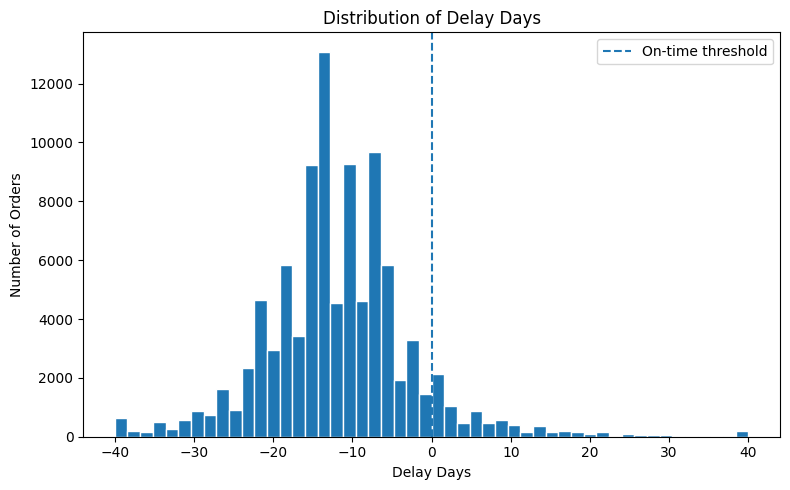

,delivery_days,delay_days,estimated_window
count,96470.000000,96470.000000,96470.000000
mean,12.093604,-11.875889,23.372748
std,9.551380,10.182105,8.758421
min,0.000000,-147.000000,2.000000
25%,6.000000,-17.000000,18.000000
50%,10.000000,-12.000000,23.000000
75%,15.000000,-7.000000,28.000000
max,209.000000,188.000000,155.000000


In [ ]:
# ============================================================
# 4.2 Delivery time and delay distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df['delivery_days'].clip(0, 60), bins=50, edgecolor='white')
plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['delay_days'].clip(-40, 40), bins=50, edgecolor='white')
plt.axvline(0, linestyle='--', label='On-time threshold')
plt.title('Distribution of Delay Days')
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

df[['delivery_days', 'delay_days', 'estimated_window']].describe()

The distribution of delay days is mostly below zero, which means most orders were delivered earlier than the estimated delivery date. This supports the earlier observation that Olist's estimated delivery windows appear relatively conservative.

However, the positive tail still represents delayed orders. These cases are important because they reflect orders where actual delivery exceeded customer expectations.

### 4.3 Delay rate by purchase month

Next, I examine whether delivery delay varies by purchase month. Monthly patterns may reflect seasonality, promotional periods, or temporary logistics pressure. This is useful because month-level features may help explain variation in delivery performance.

,order_count,delay_rate,avg_delivery_days,avg_delay_days
purchase_month,,,,
1,7819,0.054,13.489,-14.323
2,8208,0.119,15.723,-10.487
3,9549,0.151,14.942,-8.001
4,9101,0.050,11.885,-12.915
5,10294,0.053,10.891,-12.641
6,9231,0.018,9.702,-17.003
7,10028,0.032,9.518,-11.839
8,10544,0.049,8.644,-10.125
9,4151,0.044,11.411,-11.337


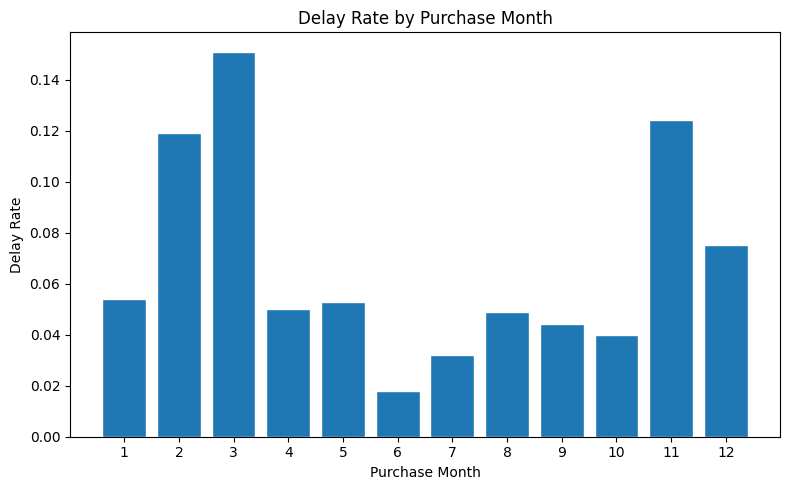

In [ ]:
# ============================================================
# 4.3 Delay rate by purchase month
# ============================================================

monthly_delay = df.groupby('purchase_month').agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean')
).round(3)

display(monthly_delay)

plt.figure(figsize=(8, 5))
plt.bar(monthly_delay.index, monthly_delay['delay_rate'], edgecolor='white')
plt.title('Delay Rate by Purchase Month')
plt.xlabel('Purchase Month')
plt.ylabel('Delay Rate')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Delay rates vary across purchase months, suggesting a seasonal pattern in logistics performance. March and November show particularly high delay rates, while June has the lowest delay rate. The high delay rate in November may be related to Black Friday demand pressure, which is explored further using the peak-season indicator.

### 4.4 Holiday and peak-season effects

This step compares delay rates across holiday and peak-season indicators. Since public holidays, Black Friday, and Christmas may affect demand and logistics capacity, these variables are examined before being included in modelling.

,value,order_count,delay_rate,avg_delivery_days,avg_delay_days,avg_review_score,feature
0,0,71988,0.072,12.038,-11.820,4.153,is_holiday_period
1,1,24482,0.056,12.256,-12.041,4.187,is_holiday_period
2,0,92215,0.063,11.907,-12.109,4.175,is_black_friday_period
3,1,4255,0.170,16.130,-6.818,3.866,is_black_friday_period
4,0,94216,0.068,12.041,-11.814,4.161,is_christmas_period
5,1,2254,0.047,14.307,-14.459,4.199,is_christmas_period


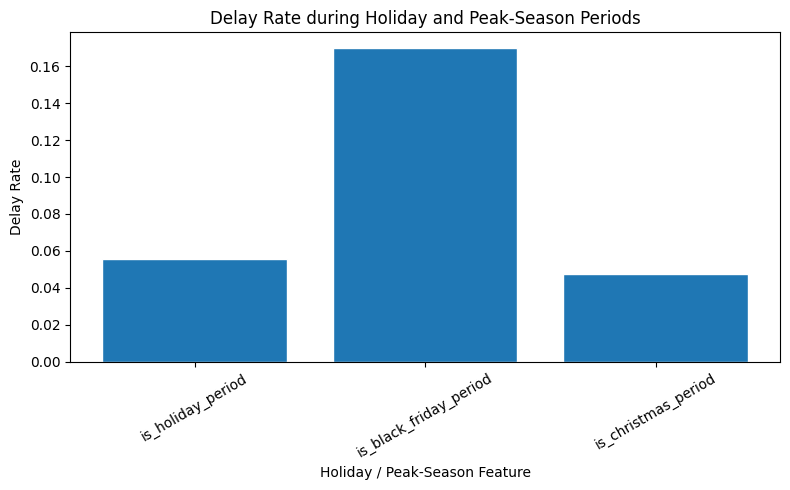

In [ ]:
# ============================================================
# 4.4 Holiday and peak-season effects
# ============================================================

holiday_features = [
    'is_holiday_period',
    'is_black_friday_period',
    'is_christmas_period'
]

holiday_summary = []

for col in holiday_features:
    temp = df.groupby(col).agg(
        order_count=('order_id', 'count'),
        delay_rate=('is_delayed', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delay_days=('delay_days', 'mean'),
        avg_review_score=('review_score', 'mean')
    ).round(3)

    temp['feature'] = col
    holiday_summary.append(temp.reset_index().rename(columns={col: 'value'}))

holiday_summary = pd.concat(holiday_summary, ignore_index=True)
display(holiday_summary)

# Plot delay rate for each holiday-related feature
holiday_delay_rates = {
    col: df[df[col] == 1]['is_delayed'].mean()
    for col in holiday_features
}

plt.figure(figsize=(8, 5))
plt.bar(holiday_delay_rates.keys(), holiday_delay_rates.values(), edgecolor='white')
plt.title('Delay Rate during Holiday and Peak-Season Periods')
plt.xlabel('Holiday / Peak-Season Feature')
plt.ylabel('Delay Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The Black Friday period shows the highest delay rate among the external calendar variables, reaching around 17%. This is much higher than the overall delay rate of 6.77%. In contrast, the general public holiday period and Christmas period do not show higher delay risk.

This suggests that logistics delay is more strongly associated with demand surge events than with public holidays in general. Therefore, Black Friday may be a more useful contextual feature for delay prediction than a broad public-holiday indicator.

### 4.5 Cross-state logistics effect

The variable `is_cross_state` indicates whether the customer and seller are located in different states. This is used as a simple proxy for logistics distance or route complexity. I compare same-state and cross-state orders to examine whether cross-state delivery is associated with longer delivery time or higher delay risk.

,order_count,delay_rate,avg_delivery_days,avg_delay_days,avg_freight,avg_review_score
is_cross_state,,,,,,
Same State,34701,0.045,7.482,-10.333,15.453,4.268
Cross State,61769,0.080,14.684,-12.743,26.905,4.102


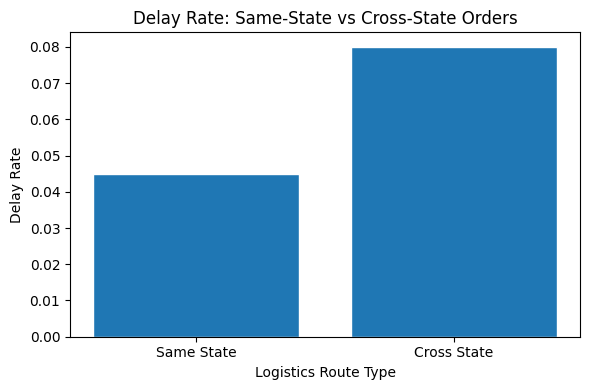

In [ ]:
# ============================================================
# 4.5 Cross-state logistics effect
# ============================================================

cross_state_summary = df.groupby('is_cross_state').agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_freight=('total_freight', 'mean'),
    avg_review_score=('review_score', 'mean')
).round(3)

cross_state_summary.index = cross_state_summary.index.map({
    0: 'Same State',
    1: 'Cross State'
})

display(cross_state_summary)

plt.figure(figsize=(6, 4))
plt.bar(cross_state_summary.index, cross_state_summary['delay_rate'], edgecolor='white')
plt.title('Delay Rate: Same-State vs Cross-State Orders')
plt.xlabel('Logistics Route Type')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()

Cross-state orders show higher logistics risk than same-state orders. Their delay rate is 8.0%, compared with 4.5% for same-state orders. They also take longer to deliver, with an average delivery duration of 14.68 days compared with 7.48 days for same-state orders. The higher average freight cost further suggests that cross-state orders involve more complex or longer logistics routes.

This supports the use of `is_cross_state` as an important logistics-related feature in the modelling stage.

### 4.6 Review score and delivery delay

Finally, I examine the relationship between delivery delay and customer review score. This helps connect logistics performance with customer satisfaction. If delayed orders have lower review scores, delivery performance may be an important driver of customer experience.

,order_count,avg_review_score,avg_delivery_days,avg_delay_days
is_delayed,,,,
On-time / Early,89936,4.294,10.539,-13.51
Delayed,6534,2.336,33.488,10.62


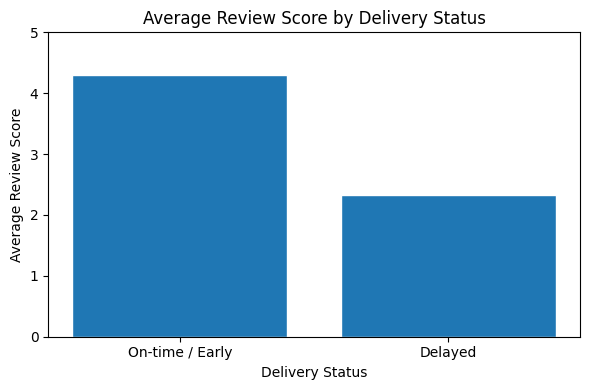

In [ ]:
# ============================================================
# 4.6 Review score and delivery delay
# ============================================================

review_by_delay = df.groupby('is_delayed').agg(
    order_count=('order_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean')
).round(3)

review_by_delay.index = review_by_delay.index.map({
    0: 'On-time / Early',
    1: 'Delayed'
})

display(review_by_delay)

plt.figure(figsize=(6, 4))
plt.bar(review_by_delay.index, review_by_delay['avg_review_score'], edgecolor='white')
plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Although delayed orders account for only 6.77% of the dataset, they are strongly associated with lower customer satisfaction. The average review score for delayed orders is 2.34, compared with 4.29 for on-time or early orders.

This suggests that delay prediction is business-relevant even though delayed orders are a minority class. Identifying delayed orders early may help prioritise customer communication, delivery monitoring, or service recovery actions.

### 4.7 Seller concurrent load and delivery delay

This section examines whether seller-side capacity pressure is associated with delivery delay. If sellers handling more active orders at the time of a new purchase are more likely to delay, this supports the queuing theory motivation for including this variable.

In [ ]:
# ============================================================
# 4.7a Delay rate by seller concurrent load quartile
# ============================================================
# Compare delay rates by seller-load quartile to test whether capacity pressure has a graded relationship with delivery delay.

df['seller_load_quartile'] = pd.qcut(
    df['seller_concurrent_load_max'],
    q=4,
    duplicates='drop'
)

# Summarize order count, delay rate, delivery time, and review score to connect seller load with operational and customer-experience outcomes.
seller_load_delay = df.groupby('seller_load_quartile', observed=True).agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_review_score=('review_score', 'mean')
).reset_index()

display(seller_load_delay)

# The bar chart makes it easier to see whether delay risk rises or concentrates non-linearly across load quartiles.
plt.figure(figsize=(8, 5))
plt.bar(
    seller_load_delay['seller_load_quartile'].astype(str),
    seller_load_delay['delay_rate'],
    edgecolor='white'
)
plt.title('Delay Rate by Seller Concurrent Load Quartile')
plt.xlabel('Seller concurrent load (quartile)')
plt.ylabel('Delay rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

*Interpret the chart here based on actual results. Example:*
Higher seller concurrent load is associated with [higher/similar] delay rates. This suggests that seller-side capacity pressure [is/is not] a meaningful factor in delivery delays. [If non-linear:] The relationship appears non-linear, with delay risk concentrating mainly in the highest load quartile.

In [ ]:
# ============================================================
# 4.7b Seller load during Black Friday vs normal periods
# ============================================================
# Compare Black Friday with normal periods to assess whether seasonal effects may operate through seller capacity pressure.

load_by_bf = df.groupby('is_black_friday_period').agg(
    order_count=('order_id', 'count'),
    avg_seller_load=('seller_concurrent_load_max', 'mean'),
    median_seller_load=('seller_concurrent_load_max', 'median'),
    delay_rate=('is_delayed', 'mean')
).round(3)

# Convert binary labels into readable period names for easier interpretation.
load_by_bf.index = load_by_bf.index.map({0: 'Normal period', 1: 'Black Friday period'})

print("Seller load comparison: Black Friday vs normal periods")
display(load_by_bf)

*Interpret based on actual results. If Black Friday shows higher seller load:*
Black Friday is not only a calendar indicator. It represents a demand-surge period that increases seller-side workload, suggesting that its effect on delay may partly operate through seller capacity pressure rather than being a pure seasonal dummy.

### 4.8 EDA summary

The exploratory analysis reveals several important logistics patterns. First, the target variable is highly imbalanced: only 6.77% of delivered orders are classified as delayed, while 93.23% are delivered on time or earlier than the estimated date. This means that delay is a minority event, and supervised learning should not rely on accuracy alone.

Second, most orders are delivered earlier than expected, suggesting that Olist's estimated delivery windows are generally conservative. However, delayed orders still represent important exceptions because they are associated with substantially longer delivery duration and lower customer review scores.

Third, logistics route complexity appears to matter. Cross-state orders have a higher delay rate, longer delivery duration, and higher freight cost than same-state orders. This suggests that cross-state delivery can be used as a useful proxy for logistics complexity.

Fourth, seasonality and peak demand periods also matter. Delay rates vary by purchase month, with higher delay rates in months such as March and November. The Black Friday period shows a particularly high delay rate, suggesting that demand surge events may create stronger delivery risk than public holidays in general.

Overall, the EDA suggests that delivery delay is a relatively rare but business-critical event. The following modelling sections will therefore focus on identifying different logistics order profiles through clustering and predicting delayed orders through supervised classification.

Finally, seller concurrent load shows [describe pattern] with delivery delay. Orders placed when the seller has a high active workload are [more/less] likely to be delayed, suggesting that supply-side capacity pressure is a relevant factor beyond static order characteristics.

## 5. Unsupervised Learning — K-Means Clustering

Before building supervised models to predict delivery delay, I first apply K-Means clustering to identify natural groups of orders based on logistics characteristics. This section follows a standard K-Means clustering workflow: selecting relevant numerical features, standardising the data, choosing the number of clusters, fitting the model, and interpreting the resulting cluster profiles.

Clustering answers a different question from supervised learning. Instead of asking whether an order will be delayed, clustering asks what types of logistics orders exist. The delay label is not used to form the clusters. After clusters are created, I compare their delay rates, delivery duration, and review scores to understand whether different logistics profiles are associated with different levels of operational risk.

### 5.1 Prepare clustering data

Following the teacher's clustering approach, I first select variables that describe the logistics profile of each order. These variables include freight cost, product weight, product volume, estimated delivery window, cross-state delivery, peak-season period, and item count.

The target variable `is_delayed` is not included in the clustering features because K-Means is an unsupervised learning method. However, I keep `is_delayed`, `delivery_days`, `delay_days`, and `review_score` in a separate clustering dataset so that I can interpret the outcomes of each cluster after the clusters are formed.

Because K-Means uses Euclidean distance, features must be standardised before clustering. I use `preprocessing.scale()` to transform the clustering variables into z-scores, following the teacher's notebook.

In [ ]:
# ============================================================
# 5.1 Prepare clustering data
# ============================================================

# Create a combined peak-season indicator
# This combines Black Friday and Christmas periods as contextual peak-season periods.
df['is_peak_season'] = (
    (df['is_black_friday_period'] == 1) |
    (df['is_christmas_period'] == 1)
).astype(int)

# Select logistics-related features for clustering
# These describe the order profile and are known before the delivery outcome.
cluster_features = [
    'total_freight',
    'product_weight_g',
    'product_volume_cm3',
    'estimated_window',
    'is_cross_state',
    'is_peak_season',
    'item_count'
]

# Keep clustering features and outcome variables for later interpretation
df_cluster = df[
    cluster_features + [
        'order_id',
        'is_delayed',
        'delay_days',
        'delivery_days',
        'review_score'
    ]
].dropna().copy()

# Feature matrix for clustering
X_cluster = df_cluster[cluster_features].copy()

# Standardise features using z-score normalisation
# This follows the teacher's approach using preprocessing.scale().
X_cluster_norm = pd.DataFrame(
    preprocessing.scale(X_cluster),
    columns=cluster_features,
    index=X_cluster.index
)

print(f"Clustering data: {X_cluster_norm.shape[0]} orders, {len(cluster_features)} features")

# Check the scaled data
display(X_cluster_norm.describe().round(2))

Clustering data: 96470 orders, 7 features


,total_freight,product_weight_g,product_volume_cm3,estimated_window,is_cross_state,is_peak_season,item_count
count,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00
mean,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.06,-0.50,-0.57,-2.44,-1.33,-0.27,-0.26
25%,-0.41,-0.44,-0.48,-0.61,-1.33,-0.27,-0.26
50%,-0.26,-0.34,-0.33,-0.04,0.75,-0.27,-0.26
75%,0.06,-0.07,0.08,0.53,0.75,-0.27,-0.26
max,82.20,38.16,48.39,15.03,0.75,3.72,36.85


The clustering dataset contains logistics-related features only, while delivery outcomes are kept separately for later interpretation.

### 5.2 Choose the number of clusters using the elbow method

To choose the number of clusters, I use the elbow method, as shown in the teacher's notebook. The elbow method calculates the within-cluster sum of squares, also called inertia or total WSS, for different values of k. As k increases, WSS decreases because more clusters can fit the data more closely. The aim is to identify a point where the improvement starts to slow down, which is known as the elbow point.

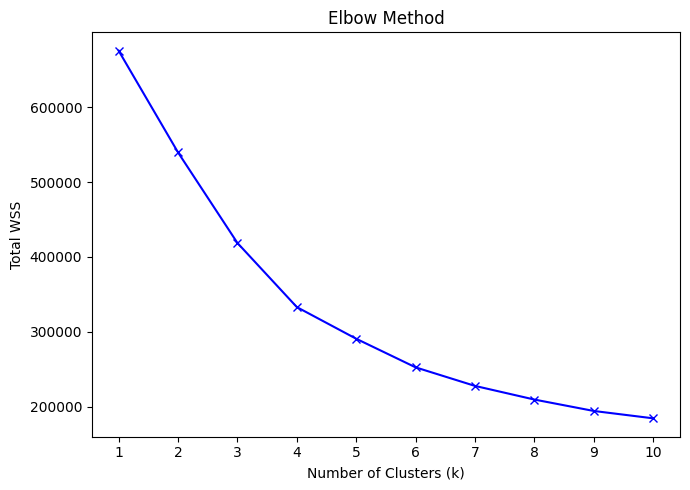

In [ ]:
# ============================================================
# 5.2 Choose k using the elbow method
# ============================================================

wss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X_cluster_norm)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Total WSS')
plt.title('Elbow Method')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

The elbow plot suggests that k = 4 is a reasonable choice because the reduction in WSS becomes smaller after four clusters.

### 5.3 Check silhouette scores

To support the elbow method, I also calculate silhouette scores for different values of k. The silhouette score measures how well each observation fits within its assigned cluster compared with other clusters. A higher score suggests better-separated clusters. I use this as a supporting check rather than the only criterion, because the final choice of k should also remain interpretable for business analysis.

In [ ]:
# ============================================================
# 5.3 Check silhouette scores
# ============================================================

from sklearn.metrics import silhouette_score

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_cluster_norm)
    sil = silhouette_score(X_cluster_norm, labels)
    print(f"k={k}, Silhouette score: {sil:.4f}")

k=2, Silhouette score: 0.5660
k=3, Silhouette score: 0.3889
k=4, Silhouette score: 0.4476
k=5, Silhouette score: 0.4606


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_5896/3929100243.py", line 10, in <cell line: 0>
    sil = silhouette_score(X_cluster_norm, labels)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_unsupervised.py", line 139, in silhouette_score
    return np.mean(silhouette_samples(X, labels, metric=metric, **kwds))
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 189, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib

TypeError: object of type 'NoneType' has no len()

Although k = 2 has the highest silhouette score, k = 4 provides a better balance between cluster separation and business interpretability.

### 5.4 Fit the final K-Means model

Based on the elbow method, silhouette scores, and business interpretability, I choose the final number of clusters and fit the K-Means model. The resulting cluster label is added back to the clustering dataset. Each cluster represents a different logistics order profile.

In [ ]:
# ============================================================
# 5.4 Fit final K-Means model
# ============================================================

# Choose k after reviewing the elbow plot and silhouette scores
CHOSEN_K = 4

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=0, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_cluster_norm)

print("Cluster sizes:")
display(df_cluster['cluster'].value_counts().sort_index())

Cluster sizes:


,count
cluster,
0,30696
1,4882
2,6364
3,54528


The final K-Means model separates the orders into four clusters with different group sizes, suggesting that some logistics profiles are more common than others.

### 5.5 Interpret cluster centroids using parallel coordinates

To understand how the clusters differ from each other, I visualise the cluster centroids using a parallel coordinates plot. Each line represents one cluster, and each axis represents one logistics feature used in the clustering model.

This plot is useful because K-Means clusters are formed from multiple variables at the same time. A parallel coordinates plot allows these variables to be compared together, rather than interpreting each feature separately. For example, it can show whether one cluster has higher freight cost, heavier products, longer estimated delivery windows, or more cross-state orders than other clusters.

The centroid values are standardised. Values above zero mean that the cluster is above the dataset average for that feature, while values below zero mean that the cluster is below the dataset average. This helps translate the K-Means output into meaningful logistics order profiles.

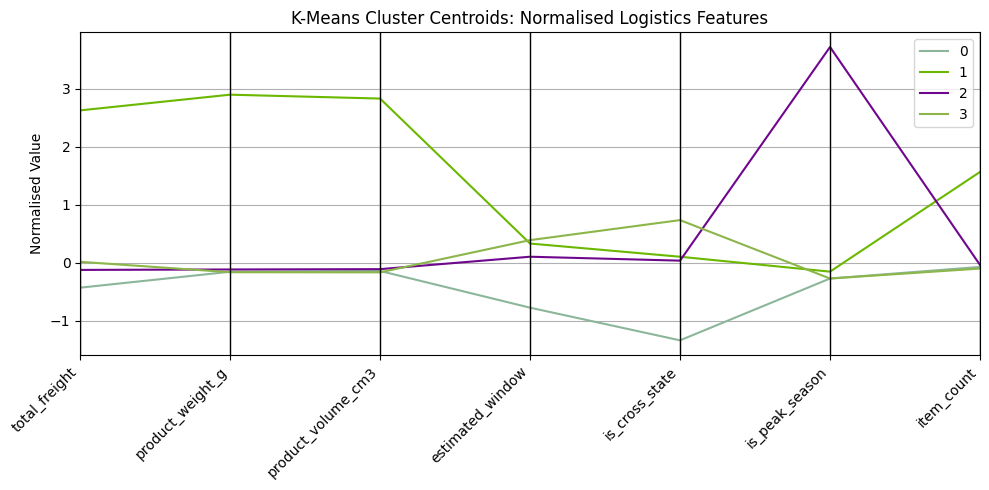

,total_freight,product_weight_g,product_volume_cm3,estimated_window,is_cross_state,is_peak_season,item_count,Cluster
0,-0.43,-0.15,-0.14,-0.77,-1.33,-0.27,-0.07,0
1,2.63,2.90,2.83,0.33,0.11,-0.15,1.57,1
2,-0.12,-0.11,-0.11,0.11,0.04,3.72,-0.04,2
3,0.02,-0.16,-0.16,0.39,0.74,-0.27,-0.10,3


In [ ]:
# ============================================================
# 5.5 Interpret cluster centroids using parallel coordinates
# ============================================================

# Create a DataFrame of normalised cluster centroids
centroids = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=cluster_features
)

centroids['Cluster'] = centroids.index.astype(str)

# Parallel coordinates plot, following the teacher's style
plt.figure(figsize=(10, 5))
parallel_coordinates(centroids, 'Cluster')
plt.title('K-Means Cluster Centroids: Normalised Logistics Features')
plt.ylabel('Normalised Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(centroids.round(2))

The parallel coordinates plot shows that the clusters differ mainly in freight cost, product size, cross-state delivery, peak-season exposure, and item count.

### 5.6 Interpret clusters using original-scale profiles

The parallel coordinates plot is useful for comparing clusters, but the values are standardised and therefore less intuitive. To make the clusters easier to interpret, I calculate the average original feature values for each cluster. This helps describe each cluster in business terms, such as lightweight local orders, cross-state high-freight orders, bulky orders, or peak-season orders.

In [ ]:
# ============================================================
# 5.6 Cluster profiles using original-scale feature values
# ============================================================

cluster_profile = df_cluster.groupby('cluster')[cluster_features].mean().round(2)

print("Cluster profiles: average feature values in original scale")
display(cluster_profile)

Cluster profiles: average feature values in original scale


,total_freight,product_weight_g,product_volume_cm3,estimated_window,is_cross_state,is_peak_season,item_count
cluster,,,,,,,
0,13.59,1658.87,13139.70,16.62,0.00,0.00,1.10
1,79.46,16213.80,102690.30,26.29,0.69,0.03,1.99
2,20.18,1846.32,14083.55,24.30,0.66,1.00,1.12
3,23.19,1621.12,12423.65,26.80,0.99,0.00,1.09


The original-scale profiles make the clusters easier to interpret as business order types, such as local low-risk orders, bulky high-freight orders, peak-season orders, and cross-state orders.

In [ ]:
# Add descriptive cluster names based on the cluster profiles
cluster_names = {
    0: 'Local low-risk orders',
    1: 'Heavy bulky high-freight orders',
    2: 'Peak-season high-delay orders',
    3: 'Standard cross-state orders'
}

df_cluster['cluster_name'] = df_cluster['cluster'].map(cluster_names)

display(
    df_cluster[['cluster', 'cluster_name']]
    .drop_duplicates()
    .sort_values('cluster')
)

,cluster,cluster_name
0,0,Local low-risk orders
10,1,Heavy bulky high-freight orders
17,2,Peak-season high-delay orders
1,3,Standard cross-state orders


### 5.7 Compare cluster outcomes

After forming clusters based only on logistics characteristics, I compare the delivery outcomes of each cluster. This step does not affect the clustering process. Instead, it helps interpret whether certain logistics profiles are associated with higher delay rates, longer delivery durations, or lower customer review scores.

In [ ]:
# ============================================================
# 5.7 Compare cluster outcomes
# ============================================================
cluster_outcomes_named = df_cluster.groupby(['cluster', 'cluster_name']).agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_review_score=('review_score', 'mean')
).round(3)

display(cluster_outcomes_named)

,,order_count,delay_rate,avg_delivery_days,avg_delay_days,avg_review_score
cluster,cluster_name,,,,,
0,Local low-risk orders,30696,0.044,7.173,-10.047,4.289
1,Heavy bulky high-freight orders,4882,0.080,14.454,-12.424,3.797
2,Peak-season high-delay orders,6364,0.127,15.443,-9.481,3.993
3,Standard cross-state orders,54528,0.073,14.261,-13.136,4.143


The cluster outcomes show that delivery risk varies across logistics profiles, with the peak-season cluster having the highest delay rate.

### 5.8 Visualise cluster-level delay risk

To make the cluster outcomes easier to compare, I visualise the delay rate for each cluster. This shows which logistics profiles are associated with higher delivery risk.

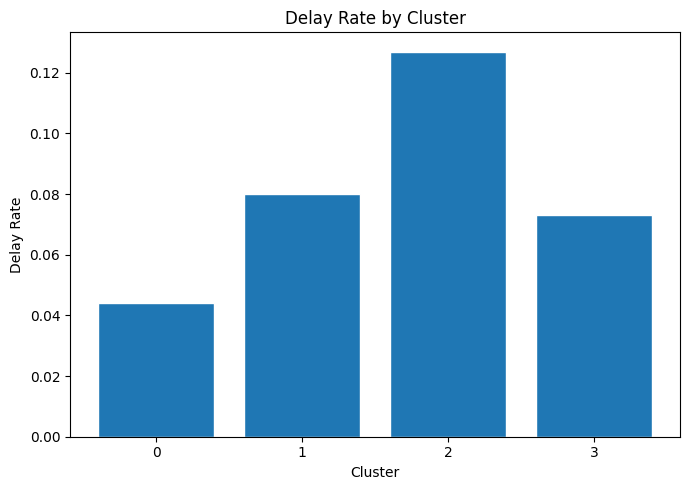

In [ ]:
# ============================================================
# 5.8 Visualise cluster-level delay risk
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(
    cluster_outcomes.index.astype(str),
    cluster_outcomes['delay_rate'],
    edgecolor='white'
)
plt.title('Delay Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()

The delay-rate chart confirms that the highest delivery risk is concentrated in one specific cluster rather than being evenly distributed across all orders.

### 5.8a Add cluster labels to main dataframe

To test whether the logistics risk profiles identified by clustering improve supervised delay prediction, cluster labels are merged back into the main analytical dataframe. Cluster membership is encoded as dummy variables so it can be used as a categorical predictor alongside other features.

Note: because clustering features overlap with some supervised model features (e.g. freight cost, product weight), cluster dummies may partially duplicate existing information. This is acknowledged, and any redundancy will be visible in the feature importance analysis.

In [ ]:
# ============================================================
# 5.8a Merge cluster labels back to main df
# ============================================================
# Merge unsupervised risk profiles back into the main dataframe so their predictive value can be tested in supervised models.

cluster_labels = df_cluster[['order_id', 'cluster']].copy()
df = df.merge(cluster_labels, on='order_id', how='left')

# Convert cluster labels into dummy variables so models such as Random Forest and XGBoost can use them as predictors.
# Create dummy variables (k=4, so 3 dummies with drop_first=True)
cluster_dummies = pd.get_dummies(df['cluster'], prefix='cluster', drop_first=True)
cluster_dummies.columns = [str(c) for c in cluster_dummies.columns]
df = pd.concat([df, cluster_dummies], axis=1)

# Store dummy-variable names so later feature definitions can reference them without hard-coding column names.
cluster_dummy_features = cluster_dummies.columns.tolist()

print("Cluster dummy variables created:", cluster_dummy_features)
print(f"Orders with cluster labels: {df['cluster'].notna().sum()}")
print(f"Orders without cluster labels: {df['cluster'].isna().sum()}")

### 5.9 Clustering summary

The K-Means clustering analysis identifies four distinct logistics order profiles. Cluster 0 represents local low-risk orders with the lowest delay rate and highest review score. Cluster 1 represents heavy bulky high-freight orders, which have longer delivery durations and lower review scores. Cluster 2 represents peak-season high-delay orders and has the highest delay rate. Cluster 3 represents standard cross-state orders, which form the largest group and show moderate delivery risk.

Overall, clustering shows that delivery risk is not evenly distributed across all orders. Instead, different logistics profiles are associated with different levels of operational risk. This provides a useful segmentation perspective before moving to supervised learning, where the next task is to predict delayed delivery directly.

## 6. Supervised Learning — Delivery Delay Classification

This section builds supervised learning models to predict whether an order will be delayed. The target variable is `is_delayed`, where 1 means the order was delivered after the estimated delivery date and 0 means the order was delivered on time or earlier.

The prediction uses only features that are available at the time of order, such as price, freight cost, product characteristics, estimated delivery window, customer-seller location relationship, purchase month, and holiday or peak-season indicators. Post-delivery variables such as `delivery_days`, `delay_days`, and `review_score` are excluded to avoid data leakage.

Because delayed orders represent only a small proportion of the dataset, this is an imbalanced classification problem. Therefore, model performance should not be evaluated using accuracy alone. I also examine precision, recall, F1-score, confusion matrix, and ROC-AUC, with particular attention to the delayed class.

### 6.0 Define modelling features

I define the modelling features using only information available before the delivery outcome is known. This prevents data leakage and makes the model closer to a real prediction setting. The selected features include order value, freight cost, product size, estimated delivery window, cross-state delivery, purchase month, external calendar indicators, seller concurrent load, and cluster-membership profiles.

In [ ]:
# ============================================================
# 6.0 Define modelling features
# ============================================================
# Split features into base, holiday, and novel groups so later comparisons can isolate each group's incremental contribution.

features_base = [
    'total_price',
    'total_freight',
    'product_weight_g',
    'product_volume_cm3',
    'estimated_window',
    'is_cross_state',
    'item_count',
    'purchase_month'
]

# Holiday and peak-season variables capture external demand shocks rather than static order characteristics.
features_holiday = [
    'is_holiday_period',
    'is_peak_season',
    'is_black_friday_period',
    'is_christmas_period'
]

# Seller concurrent load represents dynamic supply-side capacity pressure and is the main new predictor in this version.
features_seller_load = [
    'seller_concurrent_load_max'
]

# Cluster dummies bring unsupervised logistics risk profiles into the supervised model.
# Cluster dummies (created in 5.8a)
# cluster_dummy_features is already defined: ['cluster_1.0', 'cluster_2.0', 'cluster_3.0'] or similar

features_novel = features_seller_load + cluster_dummy_features

# The three feature sets support progressive comparison of base, holiday, and novel-feature contributions.
# Three feature sets for progressive comparison
features_set_A = features_base                                    # baseline
features_set_B = features_base + features_holiday                 # + holiday
features_set_C = features_base + features_holiday + features_novel # + seller load + clusters

features_all = features_set_C

# Keep only rows with complete predictors and target values so model training and testing do not fail on missing values.
# Prepare modelling dataset using the full feature set
df_model = df[features_all + ['is_delayed']].dropna().copy()

X = df_model[features_all]
y = df_model['is_delayed']

print(f"Classification data: {X.shape[0]} orders, {X.shape[1]} features")
print(f"Target: {y.mean():.2%} delayed, {1 - y.mean():.2%} on-time / early")
print(f"\nFeature set A (base):           {len(features_set_A)} features")
print(f"Feature set B (+ holiday):      {len(features_set_B)} features")
print(f"Feature set C (+ novel):        {len(features_set_C)} features")

The modelling dataset keeps only pre-delivery variables, so the models are designed to predict delay risk before the delivery outcome is observed.

### 6.1 Train-test split and scaling

I split the data into training and test sets using an 80/20 split. Because the target variable is imbalanced, I use stratification to keep the delayed-order proportion similar in both sets. Continuous features are standardised for Logistic Regression because it is scale-sensitive. Tree-based models are trained on the original unscaled data because decision trees and random forests are scale-invariant.

In [ ]:
# ============================================================
# 6.1 Train-test split and scaling
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} orders, {y_train.mean():.2%} delayed")
print(f"Test:  {X_test.shape[0]} orders, {y_test.mean():.2%} delayed")

# Scale data for Logistic Regression only
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=features_all,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features_all,
    index=X_test.index
)

print("Scaled data prepared for Logistic Regression.")

Train: 77176 orders, 6.77% delayed
Test:  19294 orders, 6.77% delayed
Scaled data prepared for Logistic Regression.


Stratification keeps the delayed-order proportion stable across training and test sets, which is important for evaluating an imbalanced classification problem.

### 6.2 Logistic Regression

Logistic Regression is used as an interpretable baseline model. Since the target variable is imbalanced, I use `class_weight='balanced'` to give more weight to delayed orders during training. This helps the model pay more attention to the minority class.

In [ ]:
# ============================================================
# 6.2 Logistic Regression
# ============================================================

logit = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

logit.fit(X_train_scaled, y_train)

y_pred_logit = logit.predict(X_test_scaled)
y_prob_logit = logit.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logit):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_logit):.4f}")
print()
print(classification_report(
    y_test,
    y_pred_logit,
    target_names=['On-time / Early', 'Delayed']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logit))

Logistic Regression Results
Accuracy: 0.6185
ROC AUC:  0.6746

                 precision    recall  f1-score   support

On-time / Early       0.96      0.62      0.75     17987
        Delayed       0.11      0.62      0.18      1307

       accuracy                           0.62     19294
      macro avg       0.53      0.62      0.47     19294
   weighted avg       0.90      0.62      0.71     19294

Confusion Matrix:
[[11123  6864]
 [  497   810]]


### 6.3 Random Forest

Random Forest is used as a tree-based model that can capture non-linear relationships and interactions between features. Unlike Logistic Regression, it does not require scaled input features. I also use class balancing to address the minority delayed class.

In [ ]:
# ============================================================
# 6.3 Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['On-time / Early', 'Delayed']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7851
ROC AUC:  0.7457

                 precision    recall  f1-score   support

On-time / Early       0.96      0.80      0.87     17987
        Delayed       0.17      0.55      0.26      1307

       accuracy                           0.79     19294
      macro avg       0.57      0.68      0.57     19294
   weighted avg       0.91      0.79      0.83     19294

Confusion Matrix:
[[14423  3564]
 [  582   725]]


### 6.4 Tuned Decision Tree using GridSearchCV

To follow a more systematic tree-based modelling approach, I tune a Decision Tree using GridSearchCV. Since the dataset is imbalanced, I use F1-score as the selection criterion rather than accuracy. This helps focus the tuning process on the model's ability to identify delayed orders.

In [ ]:
# ============================================================
# 6.4 Tuned Decision Tree using GridSearchCV
# ============================================================

param_grid = {
    'max_depth': [3, 5, 8, 10, 15],
    'min_samples_split': [20, 50, 100, 200],
    'class_weight': ['balanced']
}

gridSearch = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

gridSearch.fit(X_train, y_train)

print("Best CV F1 score:", gridSearch.best_score_)
print("Best parameters:", gridSearch.best_params_)

bestTree = gridSearch.best_estimator_

y_pred_tree = bestTree.predict(X_test)
y_prob_tree = bestTree.predict_proba(X_test)[:, 1]

print("Best Decision Tree Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_tree):.4f}")
print()
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=['On-time / Early', 'Delayed']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Best CV F1 score: 0.23451419183994698
Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_split': 50}
Best Decision Tree Results
Accuracy: 0.7336
ROC AUC:  0.7191

                 precision    recall  f1-score   support

On-time / Early       0.96      0.74      0.84     17987
        Delayed       0.15      0.61      0.24      1307

       accuracy                           0.73     19294
      macro avg       0.55      0.67      0.54     19294
   weighted avg       0.91      0.73      0.80     19294

Confusion Matrix:
[[13361  4626]
 [  514   793]]


### 6.5 XGBoost

XGBoost is a gradient boosting algorithm that often achieves strong performance in tabular classification tasks. Since the target variable is imbalanced, `scale_pos_weight` is set to the ratio of on-time to delayed orders to give more weight to the minority class.

In [ ]:
# ============================================================
# 6.5 XGBoost
# ============================================================
# Add XGBoost as a strong tabular-model benchmark to test whether boosted nonlinear models improve performance.

# Try importing XGBoost first, then install it if needed so the notebook remains reproducible in Colab.
# Install xgboost if not already available
try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

# Set scale_pos_weight using the negative-to-positive class ratio to address the low delayed-order rate.
# Calculate scale_pos_weight for imbalanced data
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
spw = n_negative / n_positive

# Use a fixed random seed and logloss evaluation metric for stable binary probability modeling.
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Save both class predictions and predicted probabilities for classification reports, ROC curves, and result summaries.
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['On-time / Early', 'Delayed']))

### 6.6 ROC curve comparison

The ROC curve compares how well each model distinguishes delayed from non-delayed orders across different probability thresholds. ROC-AUC is useful here because it evaluates ranking ability rather than relying on one fixed classification threshold.

In [ ]:
# ============================================================
# 6.6 ROC curve comparison (all models)
# ============================================================
# Plot all models on one ROC chart to compare how well each algorithm ranks delay risk.

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate ROC coordinates for each model on the same test set for a fair comparison.
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_logit)
fpr_r, tpr_r, _ = roc_curve(y_test, y_prob_rf)
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tree)
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb)

# Include AUC in the legend so the chart shows both curve shape and overall discrimination.
ax.plot(fpr_l, tpr_l, linewidth=2,
        label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_logit):.3f})")
ax.plot(fpr_r, tpr_r, linewidth=2,
        label=f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})")
ax.plot(fpr_t, tpr_t, linewidth=2,
        label=f"Tuned Decision Tree (AUC={roc_auc_score(y_test, y_prob_tree):.3f})")
ax.plot(fpr_x, tpr_x, linewidth=2,
        label=f"XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.7 Feature importance

To interpret the Random Forest model, I examine feature importance scores. These scores indicate which variables contribute most to the model's prediction decisions. This helps connect model output back to logistics and business explanations.

In [ ]:
# ============================================================
# 6.7 Feature importance from Random Forest (full feature set)
# ============================================================
# Use Random Forest importance from the full feature set to see whether seller load and cluster variables add visible predictive signal.

importances = pd.Series(rf.feature_importances_, index=features_all)
importances = importances.sort_values(ascending=True)

# A horizontal bar chart displays many feature-importance labels without crowding.
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', edgecolor='white')
plt.title('Random Forest Feature Importance (with seller load + clusters)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Display the top 10 features so the most important predictors can be referenced in the results discussion.
print("Top 10 features:")
display(importances.sort_values(ascending=False).head(10))

### 6.8 Progressive feature set comparison

To evaluate whether external holiday data and the novel seller load / cluster features improve prediction, I compare three Random Forest models trained on progressively richer feature sets:
- **Set A**: Base order-level features only
- **Set B**: Base + holiday / peak-season indicators
- **Set C**: Base + holiday + seller concurrent load + cluster membership

This progressive comparison isolates the contribution of each feature group.

In [ ]:
# ============================================================
# 6.8 Progressive feature set comparison
# ============================================================
# Add feature groups progressively to separate the performance impact of base, holiday, and novel predictors.

results_progressive = {}

# Use the same model settings across feature sets so differences mainly reflect feature content rather than hyperparameters.
for label, feat_list in [
    ('A: Base only', features_set_A),
    ('B: + Holiday', features_set_B),
    ('C: + Seller load + Clusters', features_set_C)
]:
    rf_temp = RandomForestClassifier(
        n_estimators=100, max_depth=8,
        random_state=42, n_jobs=-1, class_weight='balanced'
    )
    rf_temp.fit(X_train[feat_list], y_train)

    prob_temp = rf_temp.predict_proba(X_test[feat_list])[:, 1]
    pred_temp = rf_temp.predict(X_test[feat_list])

    # Record accuracy, ROC-AUC, delayed-class recall/F1, and feature count to evaluate both overall performance and minority-class detection.
    results_progressive[label] = {
        'Accuracy': accuracy_score(y_test, pred_temp),
        'ROC_AUC': roc_auc_score(y_test, prob_temp),
        'Delayed_Recall': classification_report(
            y_test, pred_temp, output_dict=True
        )['1']['recall'],
        'Delayed_F1': classification_report(
            y_test, pred_temp, output_dict=True
        )['1']['f1-score'],
        'N_features': len(feat_list)
    }

results_df = pd.DataFrame(results_progressive).T.round(4)
display(results_df)

# Use ROC curves to show whether richer feature sets improve ranking and discrimination.
# ROC curve comparison across feature sets
fig, ax = plt.subplots(figsize=(8, 6))

for label, feat_list in [
    ('A: Base only', features_set_A),
    ('B: + Holiday', features_set_B),
    ('C: + Seller load + Clusters', features_set_C)
]:
    rf_temp = RandomForestClassifier(
        n_estimators=100, max_depth=8,
        random_state=42, n_jobs=-1, class_weight='balanced'
    )
    rf_temp.fit(X_train[feat_list], y_train)
    prob_temp = rf_temp.predict_proba(X_test[feat_list])[:, 1]
    fpr_temp, tpr_temp, _ = roc_curve(y_test, prob_temp)
    auc_temp = roc_auc_score(y_test, prob_temp)
    ax.plot(fpr_temp, tpr_temp, linewidth=2, label=f"{label} (AUC={auc_temp:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Progressive Feature Set Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 6.9 Threshold adjustment for higher recall
# ============================================================

# Lowering the threshold can increase delayed-order recall, which suits an early-warning use case.
# Default threshold is 0.50
# Lower thresholds make the model more sensitive to delayed orders
thresholds = [0.50, 0.40, 0.30, 0.25, 0.20]

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print(classification_report(
        y_test,
        y_pred_threshold,
        target_names=['On-time / Early', 'Delayed']
    ))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_threshold))

### 6.10 Diagnostic analysis: delivery leg decomposition

To understand where delays originate in the fulfilment process, I decompose the total delivery time into three stages: (1) approval time (purchase to order approval), (2) seller processing time (approval to carrier handover), and (3) carrier transit time (carrier handover to customer delivery).

These variables use timestamps that are only available after the delivery is complete. Therefore, they are **not** included as predictors in the supervised models, as doing so would constitute data leakage. Instead, they are used diagnostically to understand the operational mechanism behind delays.

In [ ]:
# ============================================================
# 6.10 Delivery leg decomposition (diagnostic only)
# ============================================================
# Decompose delivery time to identify whether delays mainly arise from approval, seller processing, or carrier transit.

# Calculate purchase-to-approval time to assess whether order confirmation contributes to delays.
df['approval_time_days'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

# Calculate approval-to-carrier time to measure seller processing and dispatch speed.
df['seller_processing_days'] = (
    df['order_delivered_carrier_date'] - df['order_approved_at']
).dt.total_seconds() / (24 * 3600)

# Calculate carrier-to-customer time to measure the transit stage.
df['carrier_delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / (24 * 3600)

# Treat negative durations as timestamp anomalies and set them missing so they do not distort averages.
# Remove impossible negative values
for col in ['approval_time_days', 'seller_processing_days', 'carrier_delivery_days']:
    df.loc[df[col] < 0, col] = np.nan

# Summarize stage durations by delay status to compare bottlenecks between delayed and on-time orders.
leg_summary = df.groupby('is_delayed').agg(
    order_count=('order_id', 'count'),
    avg_approval_time=('approval_time_days', 'mean'),
    avg_seller_processing=('seller_processing_days', 'mean'),
    avg_carrier_delivery=('carrier_delivery_days', 'mean'),
    avg_total_delivery=('delivery_days', 'mean')
).round(2)

leg_summary.index = leg_summary.index.map({0: 'On-time / Early', 1: 'Delayed'})
print("Delivery leg decomposition by delay status")
display(leg_summary)

In [ ]:
# ============================================================
# Visualise delivery leg decomposition
# ============================================================
# Visualize average stage durations to identify where delayed orders spend additional time.

legs = ['avg_approval_time', 'avg_seller_processing', 'avg_carrier_delivery']
leg_labels = ['Approval', 'Seller processing', 'Carrier transit']

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(leg_labels))
width = 0.35

# Use on-time and delayed stage durations side by side for direct comparison.
on_time = leg_summary.loc['On-time / Early', legs].values
delayed = leg_summary.loc['Delayed', legs].values

ax.bar(x - width/2, on_time, width, label='On-time / Early', edgecolor='white')
ax.bar(x + width/2, delayed, width, label='Delayed', edgecolor='white')

ax.set_xlabel('Delivery stage')
ax.set_ylabel('Average days')
ax.set_title('Average Duration by Delivery Stage')
ax.set_xticks(x)
ax.set_xticklabels(leg_labels)
ax.legend()
plt.tight_layout()
plt.show()

*Interpret based on actual results. Example:*
The decomposition shows that delayed orders experience substantially longer [seller processing / carrier transit] times compared with on-time orders. The [seller processing / carrier transit] stage accounts for the largest share of additional time in delayed deliveries, suggesting that the primary bottleneck is [seller-side fulfilment speed / carrier-side transport capacity]. This supports the inclusion of seller concurrent load as a predictive feature, as high seller workload is likely to extend the seller processing stage.

In [ ]:
# ============================================================
# Delivery legs by seller load level
# ============================================================
# Compare delivery stages by high versus normal seller load to test whether load affects seller processing time and delay rate.

leg_by_load = df.groupby('is_high_seller_load').agg(
    order_count=('order_id', 'count'),
    avg_seller_processing=('seller_processing_days', 'mean'),
    avg_carrier_delivery=('carrier_delivery_days', 'mean'),
    delay_rate=('is_delayed', 'mean')
).round(3)

# Map the binary load indicator to readable labels for easier interpretation.
leg_by_load.index = leg_by_load.index.map({0: 'Normal load', 1: 'High load'})
print("Delivery legs by seller load level")
display(leg_by_load)

## 7. Results & Business Recommendations

### 7.1 Key results summary

This project analysed Olist logistics delivery performance by combining order-level data with external Brazilian public holiday and peak-season indicators. The final cleaned dataset contains 96,470 delivered orders. The target variable is highly imbalanced: only 6.77% of orders are delayed, while 93.23% are delivered on time or earlier than the estimated date.

The exploratory analysis shows that delayed orders are strongly associated with poorer customer experience. Delayed orders have an average review score of 2.34, compared with 4.29 for on-time or early orders. This means that delivery delay is a minority event, but it is still business-critical.

Several logistics and contextual factors are associated with delivery risk. Cross-state orders have a higher delay rate than same-state orders, suggesting that route complexity matters. Black Friday-period orders also show a much higher delay rate than general public holiday or Christmas-period orders, indicating that demand-surge periods may create stronger delivery pressure than public holidays in general.

The K-Means clustering analysis identifies four logistics order profiles: local low-risk orders, heavy bulky high-freight orders, peak-season high-delay orders, and standard cross-state orders. The highest delay rate appears in the peak-season cluster, showing that delay risk is concentrated in specific operational contexts rather than evenly distributed across all orders.

In supervised learning, Logistic Regression, Random Forest, a tuned Decision Tree, and XGBoost are compared using the expanded feature set. Because delayed orders are rare, precision and F1-score for the delayed class remain limited, so the models are more suitable as early-warning tools than as definitive delay prediction systems. The progressive feature comparison evaluates whether holiday indicators, seller concurrent load, and cluster membership add predictive value beyond baseline order-level features.

In [ ]:
# ============================================================
# 7.1 Model results summary table
# ============================================================
# Build the summary from actual model predictions so results stay consistent after rerunning the notebook.

# Collect actual results from the models above
# (Replace placeholder values with actual computed values)

results_summary = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Tuned Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logit),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_logit),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}).round(4)

# Display a concise model table for direct comparison in the results section.
display(results_summary)

### 7.2 Business recommendations

**1. Use delay prediction as an early-warning tool, not as a final decision system.**  
The Random Forest model can identify higher-risk orders better than random guessing, but it also generates false positives. Therefore, Olist should use the model to prioritise monitoring rather than to make definitive delay decisions. Orders flagged as high risk can receive closer tracking, proactive customer communication, or operational review.

**2. Prioritise Black Friday and peak-demand periods.**  
The analysis shows that Black Friday-period orders have a much higher delay rate than normal periods and that `is_black_friday_period` is one of the top predictors in the Random Forest model. Olist should prepare additional warehouse, seller support, and carrier capacity before late November. This is more important than treating all public holidays as equally risky.

**3. Monitor cross-state orders more closely.**  
Cross-state delivery is associated with higher delay rates, longer delivery duration, and higher freight cost. Olist should treat cross-state orders as higher-complexity logistics cases. These orders may benefit from more conservative delivery estimates, route-level monitoring, and earlier escalation when tracking updates are delayed.

**4. Improve delivery promise management.**  
The analysis shows that many orders are delivered earlier than the estimated delivery date, suggesting that estimated delivery windows are generally conservative. However, during peak-demand periods and cross-state delivery, delivery risk increases. Olist should use more dynamic estimated delivery dates that account for order timing, logistics route complexity, seller characteristics, and peak-season pressure.

**5. Link logistics risk to customer satisfaction management.**  
Delayed orders have much lower review scores than non-delayed orders. Olist should not only focus on reducing delay, but also on managing customer experience when delay risk is detected. For high-risk orders, proactive notifications, revised delivery expectations, or service recovery actions may help reduce customer dissatisfaction.

**Seller capacity monitoring.** The analysis reveals that seller concurrent workload is associated with delivery delay risk. Olist could implement a seller-level dashboard showing real-time active order counts and flag sellers approaching capacity thresholds. During peak-season periods such as Black Friday, temporary load redistribution or order intake limits could reduce delay risk.

### 7.3 Limitations and future improvements

The model has useful predictive signal, but its performance is limited by the available data. The current dataset does not include several direct operational variables that are likely to affect delivery delay.

First, the model uses `is_cross_state` as a proxy for logistics distance, but this is only a rough measure. Actual geographic distance between seller and customer would provide a more precise indicator of route complexity.

Second, seller-level operational performance is not fully captured. Some sellers may process and dispatch orders faster than others. Future models could include seller historical order volume, average processing time, and past delay rate, calculated only from previous orders to avoid data leakage.

Third, carrier-level information is missing. Delivery performance may depend strongly on logistics providers, route capacity, and carrier reliability. Including carrier identifiers and route-level delivery history would likely improve prediction.

Fourth, external disruption data could be added. Weather conditions, regional infrastructure, traffic disruption, and local logistics capacity may help explain delays that cannot be captured by order-level variables alone.

Finally, the prediction timing should be defined carefully. This project uses features available at order time to avoid data leakage. If the business goal is to update delay risk after order approval or seller dispatch, additional process-time variables could be used, such as approval time or seller dispatch time. These variables may improve prediction, but they belong to a different prediction scenario.

The seller concurrent load variable captures a useful signal, but it is a simplified proxy for seller capacity. The actual constraint may involve warehouse size, staff count, or product preparation complexity, none of which are observed in this dataset. Additionally, the cluster dummy variables may partially overlap with the base features used in supervised models, since clustering was performed on similar logistics characteristics. Future work could explore interaction terms between seller load and peak-season indicators to test whether holiday effects operate through seller capacity pressure, which would strengthen the causal interpretation.

### 7.4 Final conclusion

Overall, the analysis shows that Olist delivery delay is a rare but business-critical outcome. Most orders are delivered on time or earlier than estimated, but delayed orders are associated with substantially lower customer review scores. This makes delay prediction valuable even though the delayed class is small.

The project also shows that delivery risk is not evenly distributed. Cross-state orders, Black Friday-period orders, high seller concurrent load, and specific logistics clusters are more exposed to delay risk. External holiday and peak-season features, seller workload, and cluster profiles provide useful business interpretation, especially for identifying demand-surge periods and seller-side capacity pressure.

The supervised models, including Random Forest and XGBoost, should be compared using ROC-AUC and delayed-class recall rather than accuracy alone. Because of class imbalance and limited operational variables, the best model should be used as an early-warning tool rather than a definitive prediction system. The most important business value lies in using the model to prioritise monitoring, improve delivery promise management, and guide future data collection around distance, seller performance, carrier performance, and external disruption factors.